# Fidelity evaluation 

This tutorial explains how to evaluate the fidelity of synthetic smart meter data.


# Limitations

This notebook is based on the Faraday architecture, trained on Low Carbon London dataset. 
Keep in mind that these models are for demonstration purposes only and that there are 
some limitations with using these benchmarks as demonstrated here:

First, Faraday generates independent daily profiles, where we do not expect to generate
realistic multi-day profiles for particular households. Although these fidelity metrics
are well-suited for evaluating monthly/yearly synthetic profiles, Faraday is not expected to
perform particularly well, given the current architecture.

- For more information on Faraday's architecture, refer to the [Faraday paper](https://arxiv.org/abs/2404.04314).

Second, the model parameters may not result in optimal performance. Ideally, you would 
want to finetune the model parameters for your specific data set.


### Pre-requisites

1. If you haven't already, please download LCL dataset from [data.london.gov.uk](https://data.london.gov.uk/dataset/smartmeter-energy-use-data-in-london-households).
2. If you haven't already, you need to first train a model (refer to the `faraday_tutorial.ipynb` notebook).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import logging

logging.basicConfig(level=logging.INFO)

# 🗃️ Define constants

In [3]:
LCL_PROCESSED_DATA_PATH = Path("../../data/processed/historical/")
LCL_RAW_DATA_PATH = Path("../../data/raw/historical/")
TRAINED_MODEL_PATH = Path("../faraday/")

# 💿 Loading LCL Data

In [4]:
from opensynth.data_modules.lcl_data_module import LCLDataModule

data_path = LCL_PROCESSED_DATA_PATH / "train/lcl_data.csv"
stats_path = LCL_PROCESSED_DATA_PATH / "train/mean_std.csv"
outlier_path = LCL_PROCESSED_DATA_PATH / "train/outliers.csv"

# Original training data with no outliers
dm = LCLDataModule(
    data_path=data_path, stats_path=stats_path, batch_size=200, n_samples=20000
)
dm.setup()

gmm_data_module = LCLDataModule(
    data_path=data_path,
    stats_path=stats_path,
    batch_size=25000,
    n_samples=100000,
)
gmm_data_module.setup()

In [5]:
# Holdout data
holdout_path = LCL_PROCESSED_DATA_PATH / "holdout/lcl_data.csv"
dm_holdout = LCLDataModule(
    data_path=holdout_path,
    stats_path=stats_path,
    batch_size=200,
    n_samples=20000,
)
dm_holdout.setup()

# 🤖 Load Pretrained Faraday model

Here we use the `ExtendedFaradayModel` that is able to generate samples for a year.

In [6]:
from opensynth.models.faraday.stitched_model import StitchedFaradayModel
import torch

In [7]:
faraday_models = {}
for n_components in [1, 10, 50, 150]:
    faraday_models[n_components] = StitchedFaradayModel(
        torch.load(
            TRAINED_MODEL_PATH / f"faraday_model_{n_components}.pt",
            weights_only=False,
        )
    )

# 📝 Prepare data for evaluation

In [8]:
# Evaluation data imports
from opensynth.datasets.low_carbon_london.load import load_lcl_data_by_year

In [9]:
YEAR = 2013

# Load LCL data for a specific year
lcl = load_lcl_data_by_year(fname=LCL_RAW_DATA_PATH / "train.csv", year=YEAR)

# Generate Faraday samples for the same year.
# Here we use the 150 component model as example.
n_components = 150
faraday = faraday_models[n_components].generate_stitched_samples(
    gmm_data_module, year=YEAR, period="year", n_samples=500
)

# Create benchmark data structure: a dict with dataset name as key
# and a DataFrame with generated samples as value.
# The DataFrame should be in wide format, with timestamps as index (or as a separate datetime column
# in the case of polars) and samples / households as columns.
benchmark_set = {
    "LCL": lcl,
    f"faraday_{n_components}": faraday,
}

INFO:opensynth.datasets.low_carbon_london.load:Loading LCL data from /home/sagemaker-user/synthetic_data/opensynth/OpenSynth/data/raw/historical/train.csv...
INFO:opensynth.datasets.low_carbon_london.load:Selecting year 2013


  0%|          | 0/12 [00:00<?, ?it/s]

# 📅 Seasonal peaks 

In [10]:
from opensynth.evaluation.fidelity.seasonal_statistics import (
    calculate_seasonal_peaks,
    plot_seasonal_stats,
    pairwise_seasonal_kstest,
)

In [11]:
# Calculate number of peaks (quantile 0.8) per season.
# Here, we only use high peaks as the LCL data does not have generation.
result = calculate_seasonal_peaks(
    benchmark_set,
    high_low="high",
)

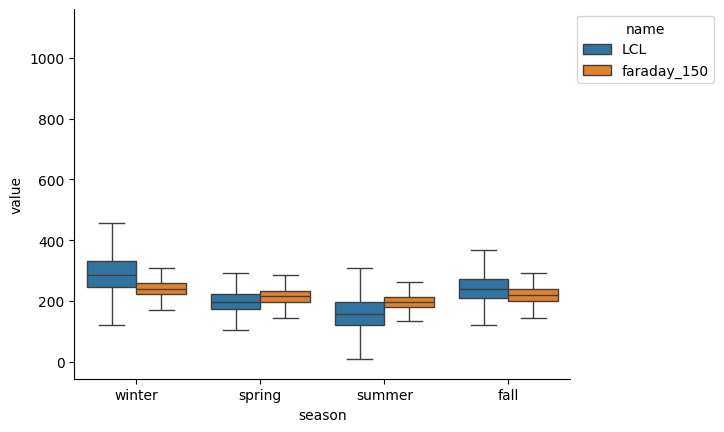

In [12]:
plot_seasonal_stats(result)

In [13]:
# Print the result of a pairwise Kolmogorov-Smirnov test per season.
pairwise_seasonal_kstest(result, "LCL", f"faraday_{n_components}")

,statistic,p_value,season
0,0.2495,2.420634e-22,spring
1,0.4510,4.323921e-74,summer
2,0.2700,3.842812e-26,fall
3,0.4540,4.061947e-75,winter


# 📈 Auto-correlation comparison

In [14]:
from opensynth.evaluation.fidelity.autocorrelation import (
    calculate_auto_correlation,
    plot_autocorrelation_stats,
    pairwise_autocorrelation_kstest,
)

In [15]:
result = calculate_auto_correlation(benchmark_set)

/home/sagemaker-user/synthetic_data/opensynth/OpenSynth/src/opensynth/evaluation/fidelity/autocorrelation.py:134: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearsonr(


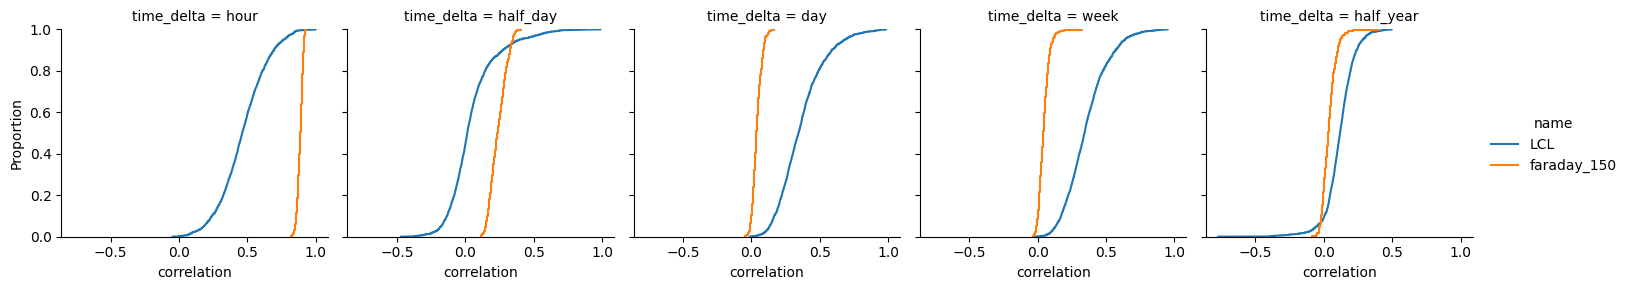

In [16]:
plot_autocorrelation_stats(result)

In [17]:
pairwise_autocorrelation_kstest(result, "LCL", f"faraday_{n_components}")

,statistic,p_value,time_delta
0,0.976305,5.928788e-323,hour
1,0.770688,3.398114e-239,half_day
2,0.945691,1.383384e-322,day
3,0.929564,1.778636e-322,week
4,0.503763,2.098622e-92,half_year
